# 02 · EDA — `merc_engineered.csv` (Random Forest readiness)

Detailed exploratory analysis of the **engineered / spec-enriched** Mercedes pool
(`data/interim/merc_engineered.csv`) to guide a **Random Forest Regressor** predicting
`price_rm` (resale price in RM).

The pool combines UK + Germany listings (FX-converted to RM) enriched with scraped specs.

**Columns by role**
- **Target:** `price_rm`
- **Raw listing:** `model_class`, `year`, `mileage`, `transmission`, `fuel_type`, `engine_size`, `source_market`
- **Engineered:** `age`, `battery_soh`, `trans_adapt_offset`
- **Spec-enriched:** `variant`, `displacement_cc`, `n_cylinders`, `n_gears`, `top_speed_kmh`, `torque_nm`, `accel_0_100_s`, `boot_l`, `engine_config`, `aspiration`, `gear_type`, `front_brake`, `rear_brake`
- **Provenance:** `spec_matched`, `match_level`

Sections: overview → duplicates → missing values (report + imputation) → target
distribution (+log) → feature distributions → outlier/data-quality audit →
correlations → categorical↔price (η) → multicollinearity → baseline RF importance →
recommendations.

## 1 · Setup & load

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

# Resolve repo root by walking up until data/interim exists (notebook lives deep in backend/ml/...)
_root = pathlib.Path.cwd()
while not (_root / "data" / "interim").exists() and _root != _root.parent:
    _root = _root.parent
CSV_PATH = _root / "data" / "interim" / "merc_engineered.csv"
print("Loading:", CSV_PATH)

df = pd.read_csv(CSV_PATH)
print("shape:", df.shape)
df.head()

Loading: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\Clorox_Mercedes_26\data\interim\merc_engineered.csv


shape: (36819, 26)


,model_class,year,mileage,transmission,fuel_type,engine_size,price_rm,source_market,age,variant,displacement_cc,n_cylinders,n_gears,top_speed_kmh,torque_nm,accel_0_100_s,boot_l,engine_config,aspiration,gear_type,front_brake,rear_brake,spec_matched,match_level,battery_soh,trans_adapt_offset
0,SLK,2005.0,101388.420,Automatic,Petrol,1.8,30680,uk,21.0,MERCEDES BENZ SLK (R171) (2004-2008),1796.0,4.0,6.0,230.0,240.0,7.9,207.0,L4,naturally_aspirated,manual,Ventilated Discs,Discs,True,displacement,38.67,-0.0731
1,S,2017.0,43452.180,Automatic,Hybrid,2.1,206193,uk,9.0,MERCEDES BENZ S-Class (2017-2020),2143.0,4.0,7.0,240.0,500.0,7.6,510.0,L4,turbo,automatic,Ventilated Discs,Ventilated Discs,True,displacement,85.51,-0.0309
2,SL,2016.0,9977.908,Automatic,Petrol,5.5,294693,uk,10.0,MERCEDES BENZ SL 63 AMG (R231) (2016-Present),5461.0,8.0,7.0,249.0,900.0,4.1,365.0,V8,turbo,automatic,Ventilated Discs,Ventilated Discs,True,displacement,65.18,-0.0213
3,G,2016.0,25749.440,Automatic,Petrol,4.0,365493,uk,10.0,MERCEDES BENZ G-Class 4x4 squared (W463) (2015...,3982.0,8.0,7.0,209.0,610.0,7.4,481.0,V8,turbo,automatic,Ventilated Discs,Ventilated Discs,True,displacement,65.44,-0.0299
4,G,2016.0,6437.360,Automatic,Petrol,4.0,436293,uk,10.0,MERCEDES BENZ G-Class 4x4 squared (W463) (2015...,3982.0,8.0,7.0,209.0,610.0,7.4,481.0,V8,turbo,automatic,Ventilated Discs,Ventilated Discs,True,displacement,59.81,-0.0232


## 2 · Shape, dtypes & summary statistics

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36819 entries, 0 to 36818
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   model_class         36819 non-null  object 
 1   year                36819 non-null  float64
 2   mileage             36819 non-null  float64
 3   transmission        36819 non-null  object 
 4   fuel_type           36819 non-null  object 
 5   engine_size         36819 non-null  float64
 6   price_rm            36819 non-null  int64  
 7   source_market       36819 non-null  object 
 8   age                 36819 non-null  float64
 9   variant             36819 non-null  object 
 10  displacement_cc     36819 non-null  float64
 11  n_cylinders         36819 non-null  float64
 12  n_gears             36125 non-null  float64
 13  top_speed_kmh       35171 non-null  float64
 14  torque_nm           35537 non-null  float64
 15  accel_0_100_s       35270 non-null  float64
 16  boot

In [3]:
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
year,36819.0,2014.567370,5.551916,1995.00000,2012.00000,2016.0000,2019.0000,2023.000
mileage,36819.0,89140.958131,78631.204443,1.60934,26305.33115,68000.0000,131000.0000,500000.000
engine_size,36819.0,2.415555,0.935106,0.00000,1.99100,2.1000,2.6850,6.898
price_rm,36819.0,146253.284907,131940.947640,3025.00000,76760.00000,120891.0000,176739.5000,1994750.000
age,36819.0,11.432630,5.551916,3.00000,7.00000,10.0000,14.0000,31.000
displacement_cc,36819.0,2427.922757,933.174028,1289.00000,1991.00000,2143.0000,2987.0000,6898.000
n_cylinders,36819.0,4.763763,1.365050,4.00000,4.00000,4.0000,6.0000,12.000
n_gears,36125.0,6.969965,1.424710,4.00000,6.00000,7.0000,9.0000,9.000
top_speed_kmh,35171.0,223.599130,24.448664,130.00000,208.00000,230.0000,245.0000,349.000
torque_nm,35537.0,408.884599,3799.180707,130.00000,280.00000,320.0000,400.0000,320440.000


In [4]:
df.describe(include=["object", "bool"]).T

,count,unique,top,freq
model_class,36819,27,C,9403
transmission,36819,4,Automatic,24178
fuel_type,36819,5,Diesel,18566
source_market,36819,2,germany,24006
variant,36819,197,MERCEDES BENZ C-Class T-Modell (S205) (2014-2018),3407
engine_config,36819,8,L4,26407
aspiration,36819,4,turbo,26347
gear_type,36819,4,automatic,19877
front_brake,36819,3,Ventilated Discs,36312
rear_brake,36819,4,Discs,23909


## 3 · Duplicates

Two lenses: exact full-row duplicates, and **logical** duplicates on the raw listing
columns (same car listed twice — the engineered/spec columns are deterministic given
these, so they don't distinguish rows).

In [5]:
print("exact full-row duplicates:", int(df.duplicated().sum()))

raw_cols = ["model_class", "year", "mileage", "transmission",
            "fuel_type", "engine_size", "price_rm", "source_market"]
logical = df.duplicated(subset=raw_cols, keep=False)
print("logical duplicate rows (raw listing cols):", int(logical.sum()))
df.loc[logical].sort_values(raw_cols)

exact full-row duplicates: 0
logical duplicate rows (raw listing cols): 14


,model_class,year,mileage,transmission,fuel_type,engine_size,price_rm,source_market,age,variant,displacement_cc,n_cylinders,n_gears,top_speed_kmh,torque_nm,accel_0_100_s,boot_l,engine_config,aspiration,gear_type,front_brake,rear_brake,spec_matched,match_level,battery_soh,trans_adapt_offset
25969,CLS,2015.0,129800.0,Automatic,Diesel,3.498,151450,germany,11.0,MERCEDES BENZ CLS Class (C218) (2014-2018),3498.0,6.0,7.0,249.0,480.0,5.3,476.0,V6,turbo,automatic,Ventilated Discs,Ventilated Discs,True,displacement,62.64,-0.1183
26073,CLS,2015.0,129800.0,Automatic,Diesel,3.498,151450,germany,11.0,MERCEDES BENZ CLS Class (C218) (2014-2018),3498.0,6.0,7.0,249.0,480.0,5.3,476.0,V6,turbo,automatic,Ventilated Discs,Ventilated Discs,True,year_repr,57.60,-0.1274
25243,CLS,2015.0,150000.0,Automatic,Petrol,3.498,135845,germany,11.0,MERCEDES BENZ CLS Class (C218) (2014-2018),3498.0,6.0,7.0,249.0,480.0,5.3,476.0,V6,turbo,automatic,Ventilated Discs,Ventilated Discs,True,displacement,60.02,-0.1293
25359,CLS,2015.0,150000.0,Automatic,Petrol,3.498,135845,germany,11.0,MERCEDES BENZ CLS Class (C218) (2014-2018),3498.0,6.0,7.0,249.0,480.0,5.3,476.0,V6,turbo,automatic,Ventilated Discs,Ventilated Discs,True,year_repr,61.49,-0.1269
21418,E,2012.0,160000.0,Automatic,Petrol,2.143,85345,germany,14.0,MERCEDES BENZ E-Klasse (W212) (2009-2012),2143.0,4.0,5.0,208.0,360.0,10.3,541.0,L4,turbo,automatic,Ventilated Discs,Discs,True,displacement,53.26,-0.1286
22035,E,2012.0,160000.0,Automatic,Petrol,2.143,85345,germany,14.0,MERCEDES BENZ E-Klasse (W212) (2009-2012),2143.0,4.0,5.0,208.0,360.0,10.3,541.0,L4,turbo,automatic,Ventilated Discs,Discs,True,displacement,53.22,-0.1233
27815,GLC,2016.0,180000.0,Automatic,Diesel,2.143,138875,germany,10.0,MERCEDES BENZ GLC Coupe (C253) (2016-2019),2143.0,4.0,9.0,209.0,400.0,8.3,490.0,L4,turbo,automatic,Ventilated Discs,Ventilated Discs,True,displacement,59.20,-0.1404
27903,GLC,2016.0,180000.0,Automatic,Diesel,2.143,138875,germany,10.0,MERCEDES BENZ GLC Coupe (C253) (2016-2019),2143.0,4.0,9.0,209.0,400.0,8.3,490.0,L4,turbo,automatic,Ventilated Discs,Ventilated Discs,True,displacement,63.42,-0.1192
28436,GLC,2017.0,36800.0,Automatic,Diesel,2.143,171448,germany,9.0,MERCEDES BENZ GLC Coupe (C253) (2016-2019),2143.0,4.0,9.0,209.0,400.0,8.3,490.0,L4,turbo,automatic,Ventilated Discs,Ventilated Discs,True,displacement,64.77,-0.0194
29850,GLC,2017.0,36800.0,Automatic,Diesel,2.143,171448,germany,9.0,MERCEDES BENZ GLC Coupe (C253) (2016-2019),2143.0,4.0,9.0,209.0,400.0,8.3,490.0,L4,turbo,automatic,Ventilated Discs,Ventilated Discs,True,displacement,66.47,-0.0243


## 4 · Missing values — report & usable rows

Which columns are missing, and **how many rows remain usable** at different tolerance
thresholds.

In [6]:
miss = df.isna().sum()
missing_tbl = pd.DataFrame({"missing": miss, "pct": (miss / len(df) * 100).round(2)})
missing_tbl = missing_tbl[missing_tbl["missing"] > 0].sort_values("missing", ascending=False)
missing_tbl

,missing,pct
boot_l,4541,12.33
top_speed_kmh,1648,4.48
accel_0_100_s,1549,4.21
torque_nm,1282,3.48
n_gears,694,1.88


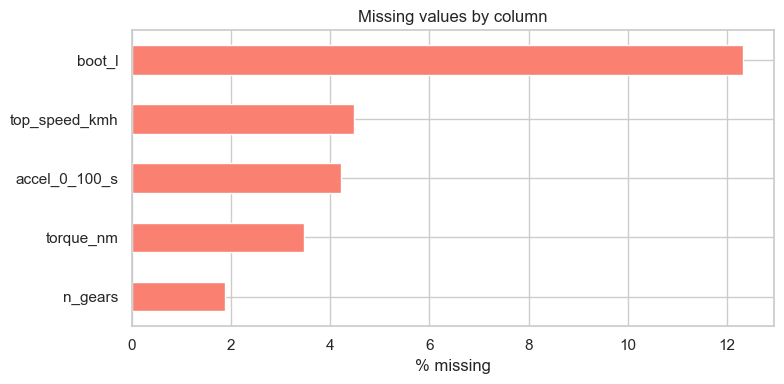

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_tbl["pct"].plot.barh(ax=ax, color="salmon")
ax.set_xlabel("% missing"); ax.set_title("Missing values by column"); ax.invert_yaxis()
plt.tight_layout()

In [8]:
row_missing = df.isna().sum(axis=1)
n = len(df)
usable = pd.DataFrame([
    {"max_missing_per_row": k,
     "usable_rows": int((row_missing <= k).sum()),
     "pct": round((row_missing <= k).mean() * 100, 1)}
    for k in range(0, int(row_missing.max()) + 1)
])
print("fully complete rows:", int((row_missing == 0).sum()),
      f"({(row_missing == 0).mean() * 100:.1f}%)")
print("rows with at least one missing:", int((row_missing > 0).sum()),
      f"({(row_missing > 0).mean() * 100:.1f}%)")
usable

fully complete rows: 30599 (83.1%)
rows with at least one missing: 6220 (16.9%)


,max_missing_per_row,usable_rows,pct
0,0,30599,83.1
1,1,34884,94.7
2,2,35278,95.8
3,3,36801,100.0
4,4,36819,100.0


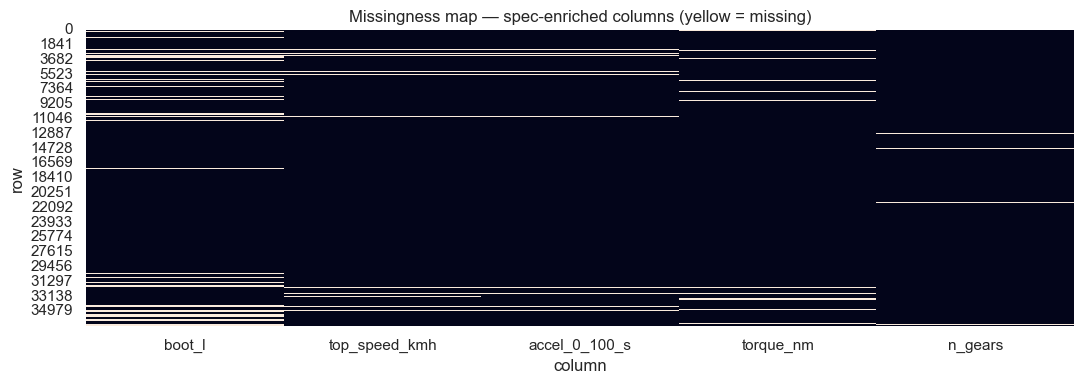

In [9]:
# Co-missingness: do the spec columns tend to be missing together?
spec_miss_cols = missing_tbl.index.tolist()
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(df[spec_miss_cols].isna(), cbar=False, ax=ax)
ax.set_title("Missingness map — spec-enriched columns (yellow = missing)")
ax.set_xlabel("column"); ax.set_ylabel("row")
plt.tight_layout()

## 5 · Prototype imputation (median / mode)

Demonstrates median-imputing the numeric spec columns (mode for any categorical) so all
rows become usable, and compares the distribution before/after for the worst column
(`boot_l`, ~12% missing). **This is a prototype — the source CSV is not modified.**

Trade-off for RF: complete-case (drop rows) keeps ~83% of data untouched but loses the
luxury/rare specs; median-impute keeps every row but flattens the imputed feature's
distribution. Recommendation is left to you in §12.

In [10]:
num_all = df.select_dtypes("number")
num_miss_cols = num_all.columns[num_all.isna().any()].tolist()
print("numeric columns to median-impute:", num_miss_cols)

df_imp = df.copy()
for c in num_miss_cols:
    df_imp[c] = df_imp[c].fillna(df_imp[c].median())
cat_miss = [c for c in df.select_dtypes(exclude="number").columns if df[c].isna().any()]
for c in cat_miss:
    df_imp[c] = df_imp[c].fillna(df_imp[c].mode().iloc[0])
print("categorical columns mode-imputed:", cat_miss)
print("remaining missing after impute:", int(df_imp.isna().sum().sum()))

pd.concat([df["boot_l"].describe().rename("before"),
           df_imp["boot_l"].describe().rename("after")], axis=1)

numeric columns to median-impute: ['n_gears', 'top_speed_kmh', 'torque_nm', 'accel_0_100_s', 'boot_l']
categorical columns mode-imputed: []
remaining missing after impute: 0


,before,after
count,32278.000000,36819.000000
mean,492.158963,491.892691
std,128.208484,120.044107
min,144.000000,144.000000
25%,436.000000,450.000000
50%,490.000000,490.000000
75%,541.000000,530.000000
max,1280.000000,1280.000000


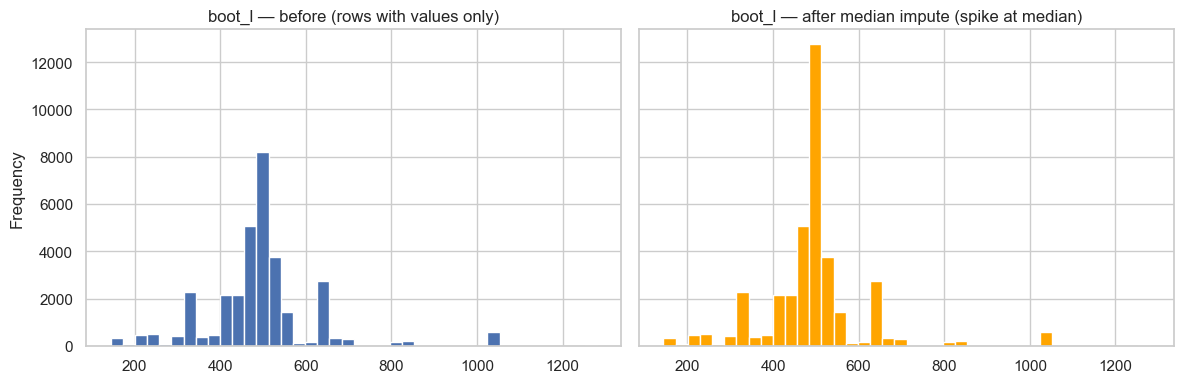

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
df["boot_l"].plot.hist(bins=40, ax=ax[0], title="boot_l — before (rows with values only)")
df_imp["boot_l"].plot.hist(bins=40, ax=ax[1], color="orange",
                           title="boot_l — after median impute (spike at median)")
plt.tight_layout()

## 6 · Target distribution — `price_rm`

Understand the shape of what we're predicting, and whether a log transform helps.

skew: 4.571  | kurtosis: 35.922
count      36819.0
mean      146253.0
std       131941.0
min         3025.0
1%         10050.0
5%         22725.0
25%        76760.0
50%       120891.0
75%       176740.0
95%       332694.0
99%       706702.0
max      1994750.0
Name: price_rm, dtype: float64


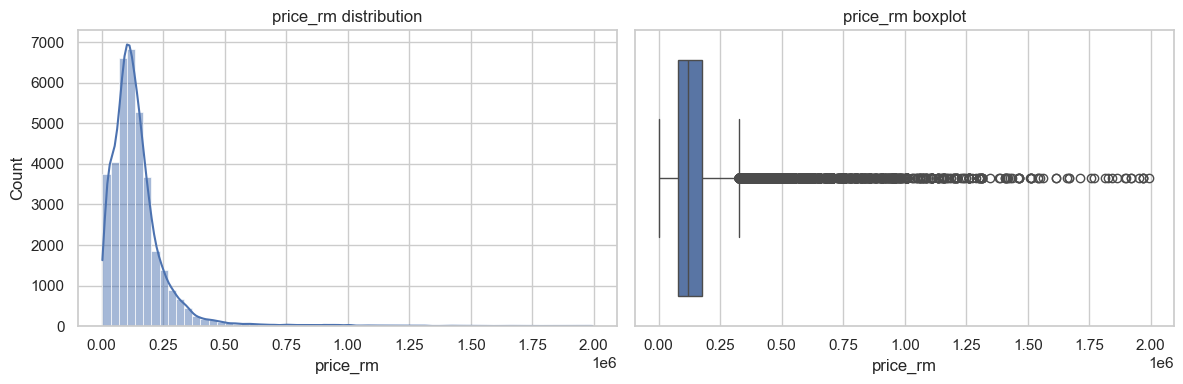

In [12]:
price = df["price_rm"]
print("skew:", round(stats.skew(price), 3), " | kurtosis:", round(stats.kurtosis(price), 3))
print(price.describe([.01, .05, .25, .5, .75, .95, .99]).round(0))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(price, bins=60, kde=True, ax=ax[0]); ax[0].set_title("price_rm distribution")
sns.boxplot(x=price, ax=ax[1]); ax[1].set_title("price_rm boxplot")
plt.tight_layout()

skew raw: 4.571 | skew log1p: -0.691


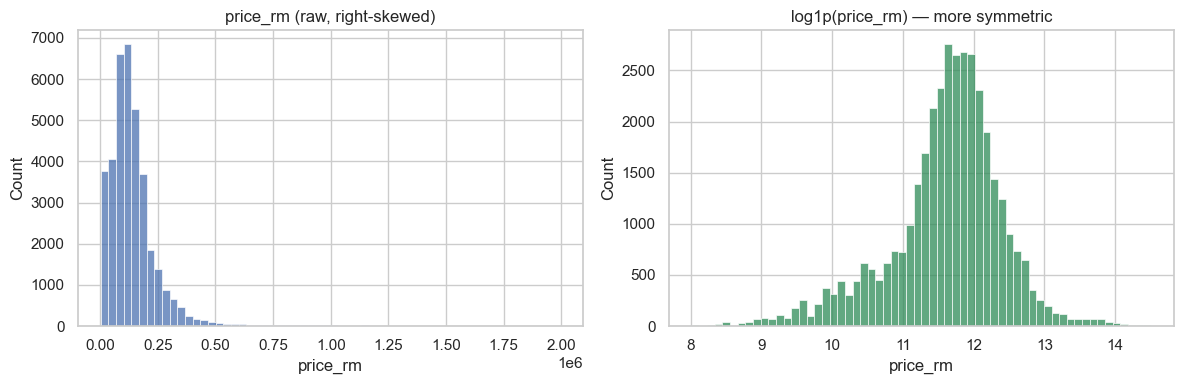

In [13]:
log_price = np.log1p(price)
print("skew raw:", round(stats.skew(price), 3),
      "| skew log1p:", round(stats.skew(log_price), 3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(price, bins=60, ax=ax[0]); ax[0].set_title("price_rm (raw, right-skewed)")
sns.histplot(log_price, bins=60, ax=ax[1], color="seagreen")
ax[1].set_title("log1p(price_rm) — more symmetric")
plt.tight_layout()

## 7 · Numeric feature distributions

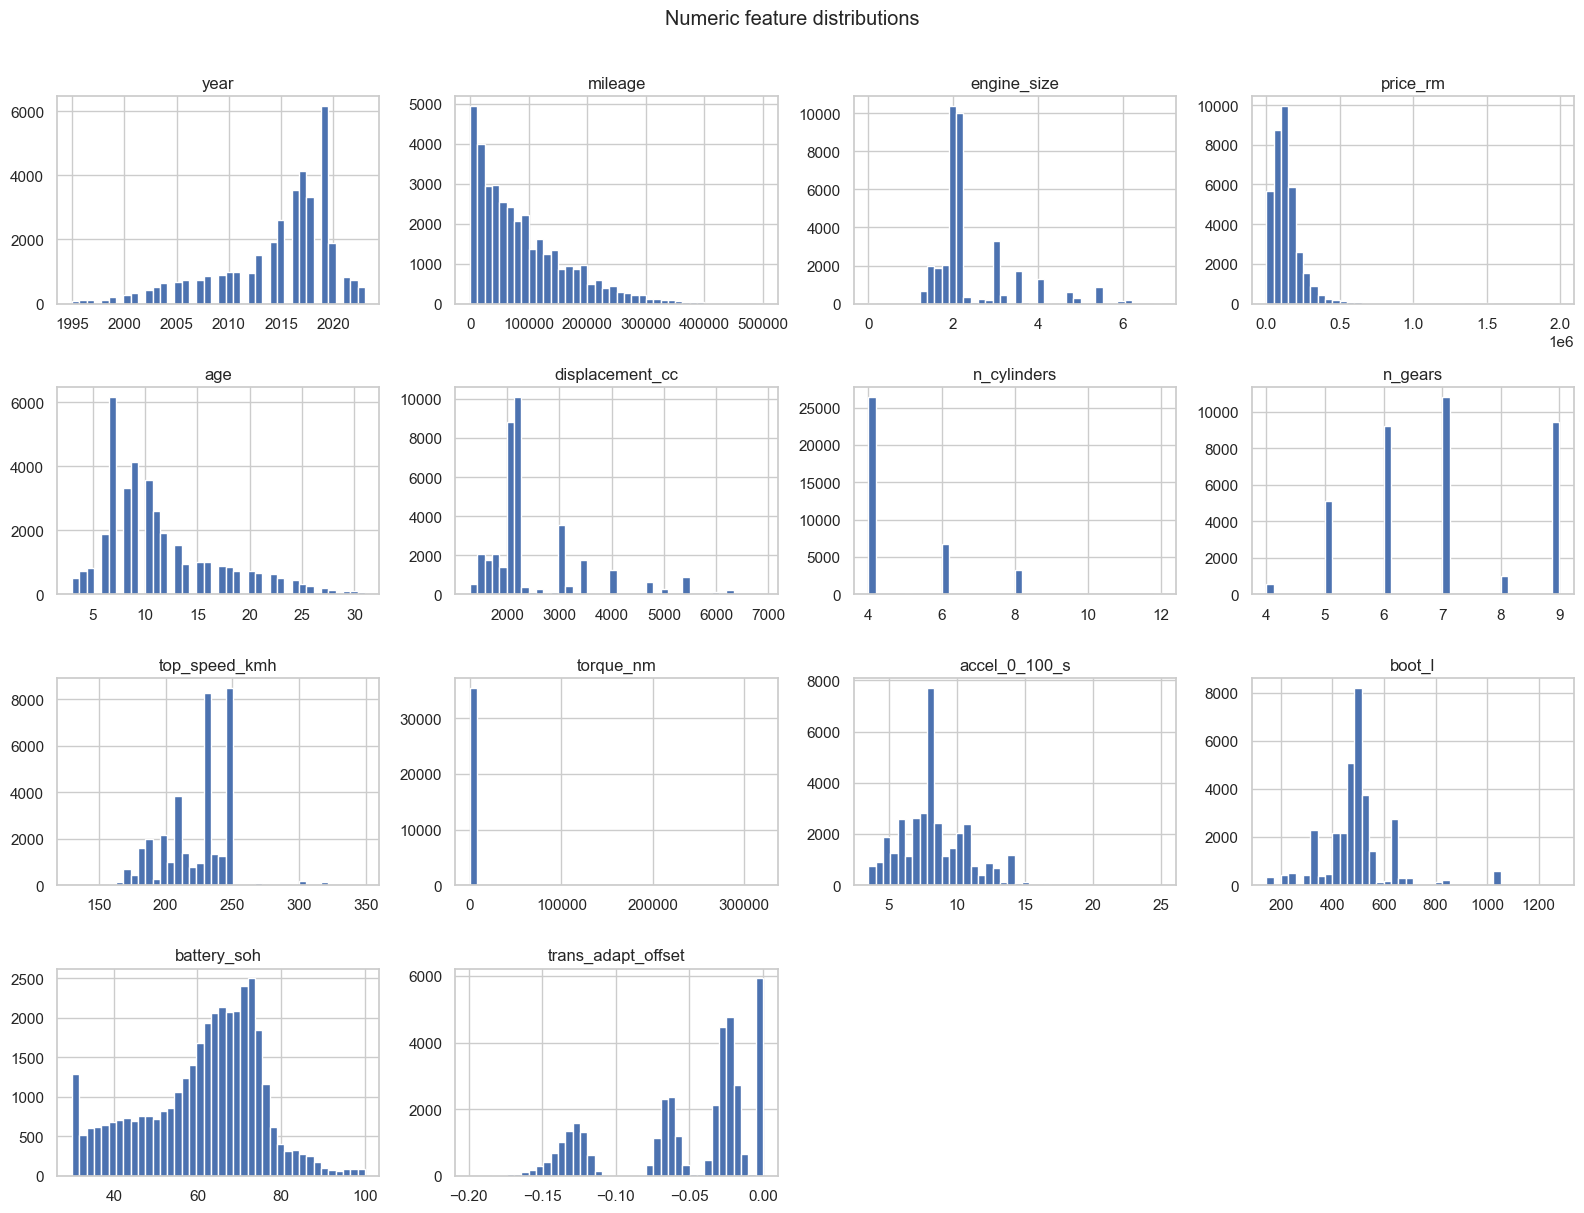

In [14]:
num_cols = df.select_dtypes("number").columns.tolist()
df[num_cols].hist(figsize=(16, 12), bins=40)
plt.suptitle("Numeric feature distributions", y=1.01)
plt.tight_layout()

In [15]:
print("engine_size == 0 rows:", int((df["engine_size"] == 0).sum()))
print("torque_nm > 2000 (broken) rows:", int((df["torque_nm"] > 2000).sum()))
df.loc[df["torque_nm"] > 2000, ["model_class", "variant", "torque_nm", "price_rm"]]

engine_size == 0 rows: 10
torque_nm > 2000 (broken) rows: 5


,model_class,variant,torque_nm,price_rm
35619,GLC,MERCEDES BENZ GLC (X254) (2022-Present),320440.0,453995
35675,GLC,MERCEDES BENZ GLC (X254) (2022-Present),320440.0,499445
35780,GLC,MERCEDES BENZ GLC (X254) (2022-Present),320440.0,363095
36239,GLC,MERCEDES BENZ GLC (X254) (2022-Present),320440.0,570145
36262,GLC,MERCEDES BENZ GLC (X254) (2022-Present),320440.0,377488


## 8 · Categorical feature distributions

In [16]:
cat_cols = df.select_dtypes(exclude="number").columns.tolist()
for c in cat_cols:
    print(f"--- {c} (nunique={df[c].nunique()}) ---")
    print(df[c].value_counts(dropna=False).head(8).to_dict())
    print()

--- model_class (nunique=27) ---
{'C': 9403, 'E': 6254, 'A': 5405, 'B': 2274, 'GLC': 2060, 'GLA': 1364, 'CLA': 1184, 'S': 1075}

--- transmission (nunique=4) ---
{'Automatic': 24178, 'Semi-Auto': 6632, 'Manual': 5919, 'Other': 90}

--- fuel_type (nunique=5) ---
{'Diesel': 18566, 'Petrol': 17284, 'Hybrid': 827, 'Other': 136, 'Electric': 6}

--- source_market (nunique=2) ---
{'germany': 24006, 'uk': 12813}

--- variant (nunique=197) ---
{'MERCEDES BENZ C-Class T-Modell (S205) (2014-2018)': 3407, 'MERCEDES BENZ E-Class T-Modell All-Terrain (S213) (2017-2020)': 1962, 'MERCEDES BENZ A-Klasse (W176) (2015-2018)': 1503, 'MERCEDES BENZ C-Class (W205) (2018-2021)': 1259, 'MERCEDES BENZ C-Class T-Modell (S205) (2018-2021)': 1181, 'MERCEDES BENZ A-Class (W177) (2018-2022)': 1140, '2013 Mercedes-Benz E-Class (W212)': 1099, 'MERCEDES BENZ C-Klasse T-Modell (S204) (2007-2011)': 900}

--- engine_config (nunique=8) ---
{'L4': 26407, 'V6': 5366, 'V8': 3310, 'L6': 1331, 'L5': 223, 'V12': 158, 'INLINE 4'

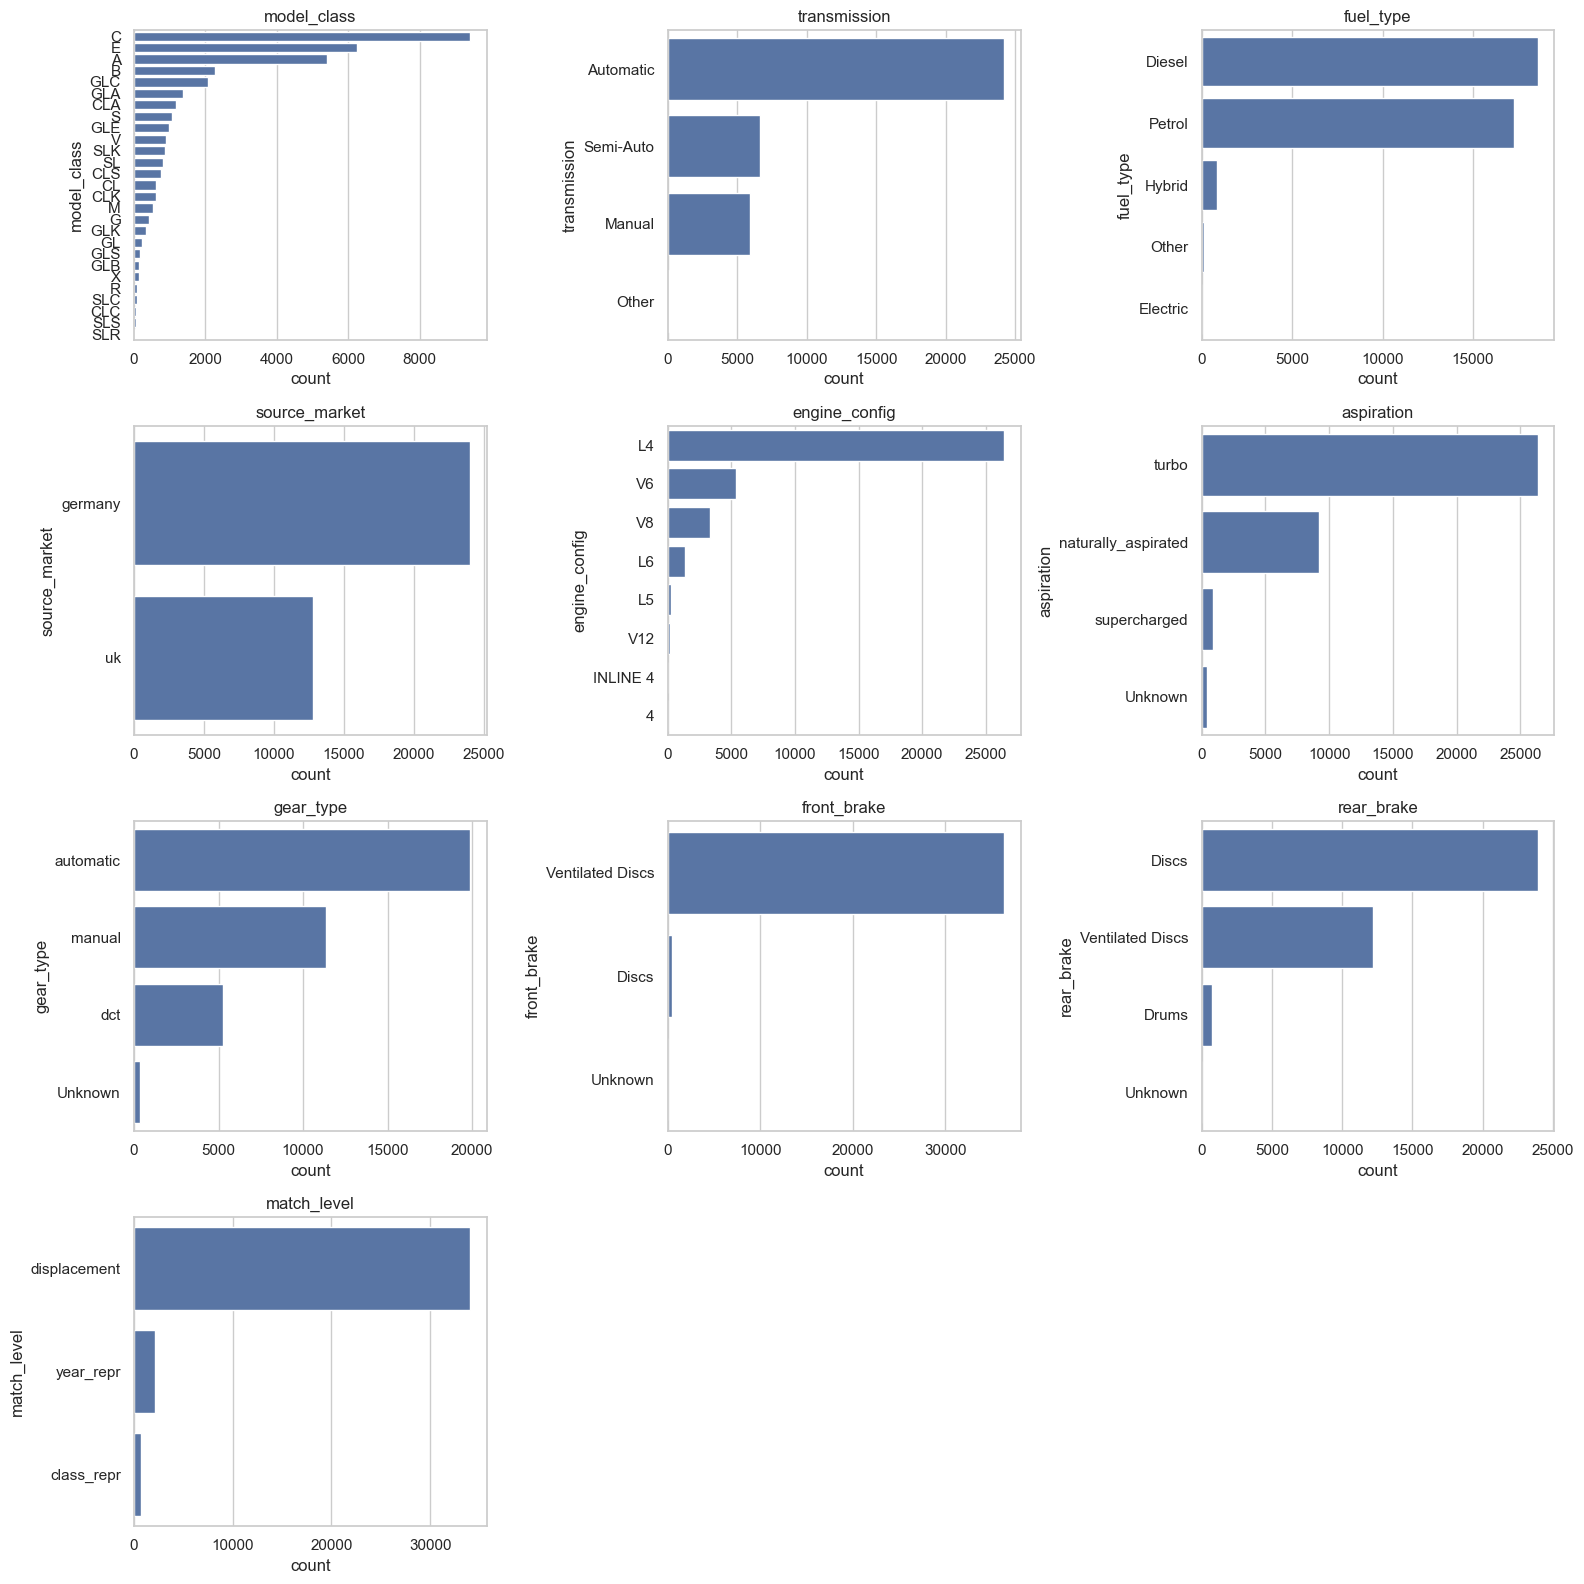

In [17]:
plot_cats = ["model_class", "transmission", "fuel_type", "source_market", "engine_config",
             "aspiration", "gear_type", "front_brake", "rear_brake", "match_level"]
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
for ax, c in zip(axes.ravel(), plot_cats):
    sns.countplot(y=c, data=df, order=df[c].value_counts().index, ax=ax)
    ax.set_title(c)
for ax in axes.ravel()[len(plot_cats):]:
    ax.set_visible(False)
plt.tight_layout()

In [18]:
print("spec_matched unique values:", df["spec_matched"].unique(),
      "-> constant (zero variance, drop candidate)")
print("variant nunique:", df["variant"].nunique(), "-> high cardinality (needs encoding)")

spec_matched unique values: [ True] -> constant (zero variance, drop candidate)
variant nunique: 197 -> high cardinality (needs encoding)


## 9 · Outlier & data-quality audit

Flag broken/implausible values and true statistical outliers. RF is robust to monotonic
outliers, but **broken values** (e.g. torque of 320,440 Nm) still corrupt splits and
correlations, so they should be fixed. Nothing is mutated here — this is a report.

In [19]:
def iqr_outliers(s):
    q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lo) | (s > hi)).sum()), round(lo, 1), round(hi, 1)

issues = [
    ("torque_nm broken (>2000 Nm)", int((df["torque_nm"] > 2000).sum()),
     "null-out then re-check correlation"),
    ("engine_size == 0", int((df["engine_size"] == 0).sum()),
     "likely EV/mis-coded; verify vs fuel_type"),
    ("spec_matched constant", "yes" if df["spec_matched"].nunique() == 1 else "no",
     "drop zero-variance column"),
]
for col in ["price_rm", "mileage"]:
    cnt, lo, hi = iqr_outliers(df[col])
    issues.append((f"{col} IQR outliers", cnt,
                   f"outside [{lo}, {hi}] — luxury/high-km tail, keep (RF-robust)"))

issues_df = pd.DataFrame(issues, columns=["check", "count / flag", "suggested_handling"])
issues_df

,check,count / flag,suggested_handling
0,torque_nm broken (>2000 Nm),5,null-out then re-check correlation
1,engine_size == 0,10,likely EV/mis-coded; verify vs fuel_type
2,spec_matched constant,yes,drop zero-variance column
3,price_rm IQR outliers,1957,"outside [-73209.2, 326708.8] — luxury/high-km ..."
4,mileage IQR outliers,883,"outside [-130736.7, 288042.0] — luxury/high-km..."


## 10 · Correlation matrix — numeric features

Pearson correlation across numeric features and with the target. `torque_nm` is shown
both raw and after nulling the broken values, to reveal its true relationship with price.

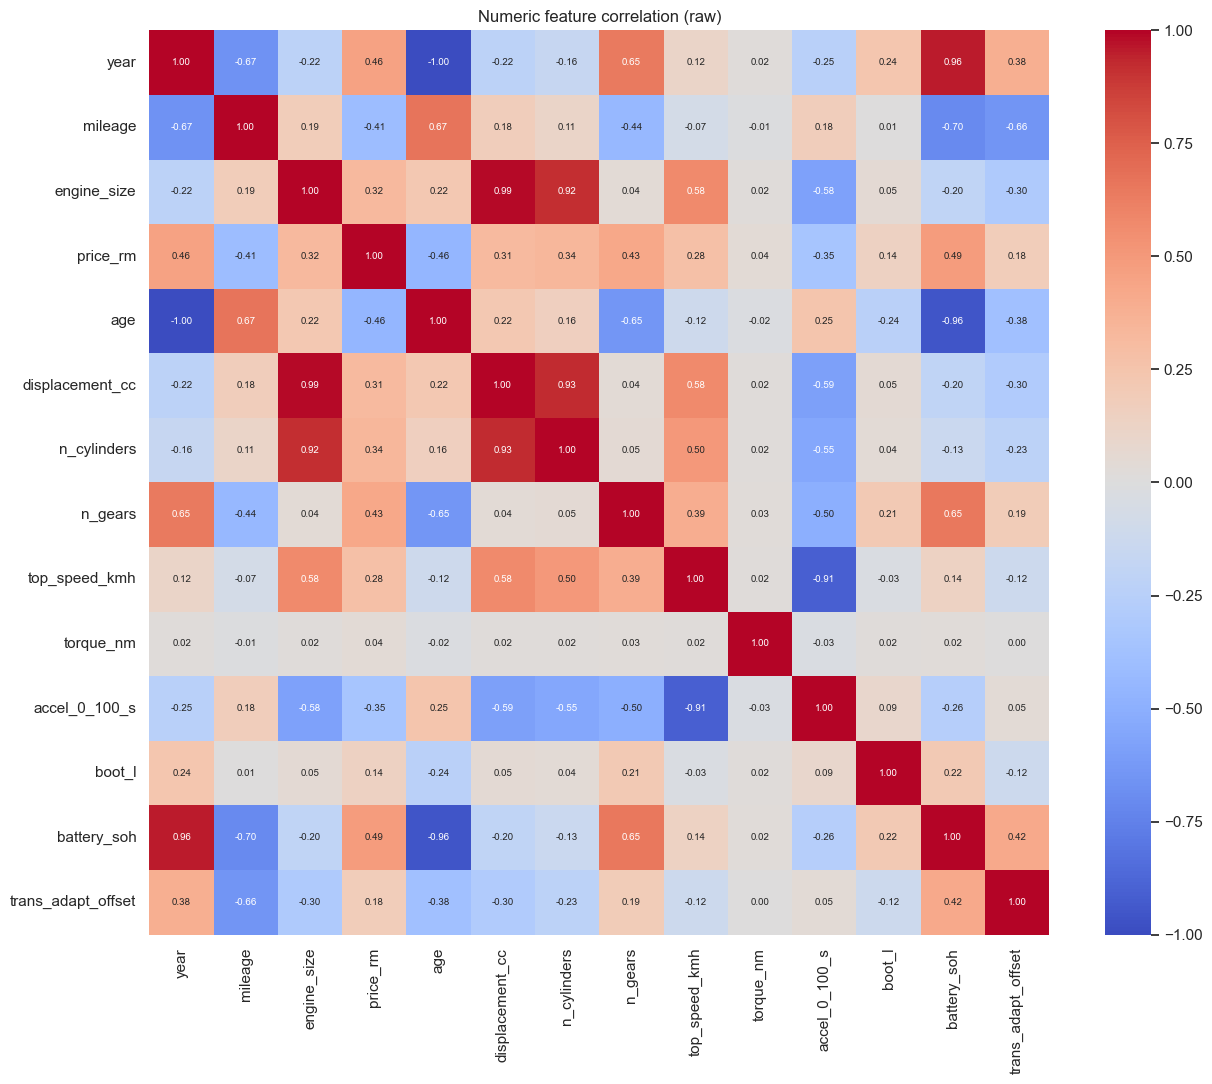

In [20]:
num = df.select_dtypes("number")
corr = num.corr()
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Numeric feature correlation (raw)")
plt.tight_layout()

torque_nm corr with price  — raw: 0.042 | cleaned: 0.395


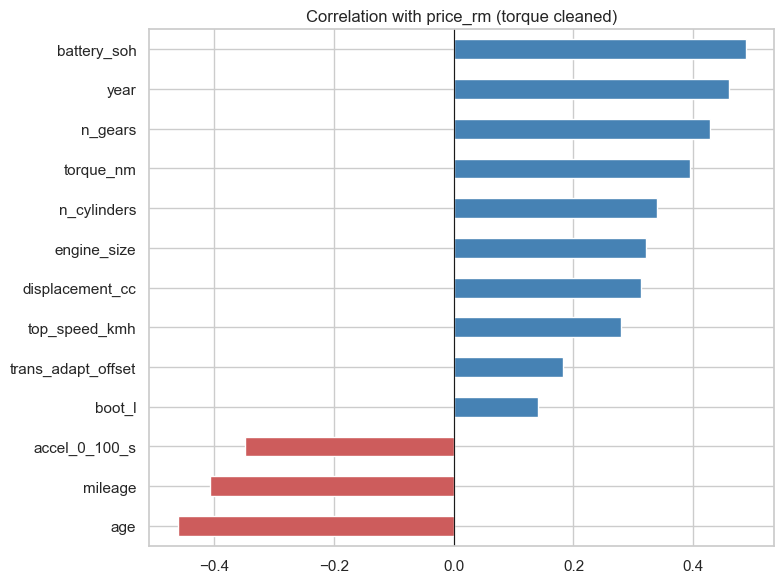

In [21]:
num_clean = num.copy()
num_clean.loc[num_clean["torque_nm"] > 2000, "torque_nm"] = np.nan
print("torque_nm corr with price  — raw:",
      round(num.corr()["price_rm"]["torque_nm"], 3),
      "| cleaned:", round(num_clean.corr()["price_rm"]["torque_nm"], 3))

price_corr = num_clean.corr()["price_rm"].drop("price_rm").sort_values()
colors = price_corr.gt(0).map({True: "steelblue", False: "indianred"})
fig, ax = plt.subplots(figsize=(8, 6))
price_corr.plot.barh(ax=ax, color=list(colors))
ax.set_title("Correlation with price_rm (torque cleaned)")
ax.axvline(0, color="k", lw=.8)
plt.tight_layout()

## 11 · Categorical ↔ price association (correlation ratio η)

Pearson can't score categoricals, so we use the **correlation ratio (η)** — the share of
price variance explained by group membership (0 = none, 1 = fully). Boxplots show the
per-category price spread.

In [22]:
def correlation_ratio(categories, values):
    cats = pd.Categorical(categories)
    codes = cats.codes
    y = np.asarray(values, dtype=float)
    ybar = y.mean()
    ss_between = sum(len(y[codes == k]) * (y[codes == k].mean() - ybar) ** 2
                     for k in range(len(cats.categories)) if (codes == k).any())
    ss_total = ((y - ybar) ** 2).sum()
    return float(np.sqrt(ss_between / ss_total)) if ss_total > 0 else 0.0

cat_cols_all = [c for c in df.select_dtypes(exclude="number").columns if df[c].nunique() > 1]
eta = pd.Series({c: round(correlation_ratio(df[c], df["price_rm"]), 3)
                 for c in cat_cols_all}).sort_values(ascending=False)
print("Correlation ratio (eta) vs price_rm:")
eta

Correlation ratio (eta) vs price_rm:


variant          0.848
model_class      0.646
match_level      0.406
engine_config    0.376
rear_brake       0.305
transmission     0.264
gear_type        0.249
aspiration       0.197
fuel_type        0.100
front_brake      0.016
source_market    0.005
dtype: float64

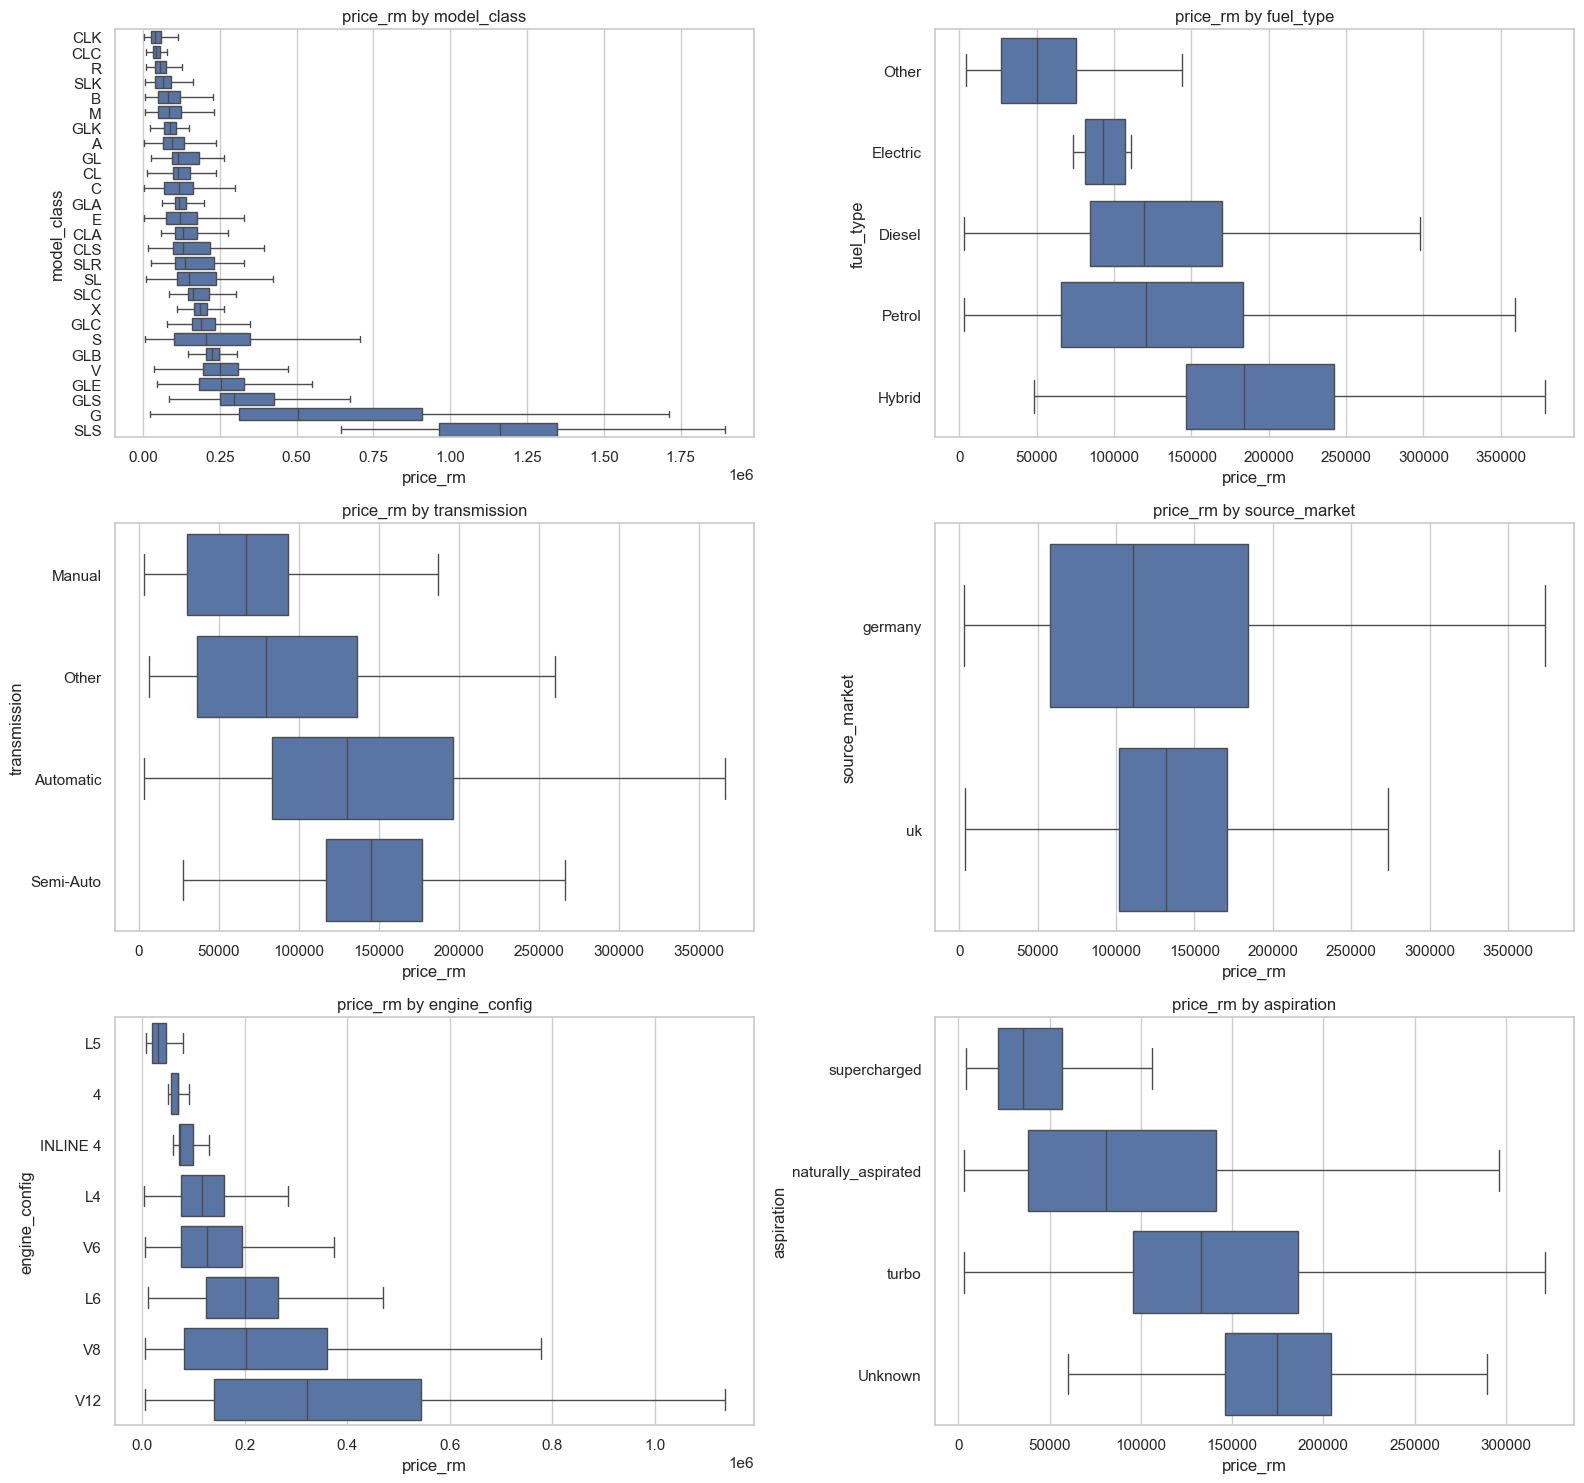

In [23]:
box_cats = ["model_class", "fuel_type", "transmission", "source_market",
            "engine_config", "aspiration"]
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
for ax, c in zip(axes.ravel(), box_cats):
    order = df.groupby(c)["price_rm"].median().sort_values().index
    sns.boxplot(x="price_rm", y=c, data=df, order=order, ax=ax, showfliers=False)
    ax.set_title(f"price_rm by {c}")
plt.tight_layout()

## 12 · Redundant features & multicollinearity

Highly correlated feature pairs carry the same signal — RF still works, but importance
gets split between them and training is slower. VIF (if `statsmodels` is available)
quantifies each feature's redundancy.

In [24]:
corr_abs = num_clean.corr().abs()
pairs = (corr_abs.where(np.triu(np.ones(corr_abs.shape), 1).astype(bool))
         .stack().sort_values(ascending=False))
print("Highly correlated feature pairs (|r| > 0.8):")
print(pairs[pairs > 0.8] if (pairs > 0.8).any() else "  none")

Highly correlated feature pairs (|r| > 0.8):
year             age                1.000000
engine_size      displacement_cc    0.990686
age              battery_soh        0.959169
year             battery_soh        0.959169
displacement_cc  n_cylinders        0.929095
engine_size      n_cylinders        0.915180
top_speed_kmh    accel_0_100_s      0.906251
dtype: float64


In [25]:
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X_vif = num_clean.drop(columns=["price_rm"]).dropna()
    vif = pd.Series([variance_inflation_factor(X_vif.values, i)
                     for i in range(X_vif.shape[1])],
                    index=X_vif.columns).sort_values(ascending=False)
    print("Variance Inflation Factor (>10 = concerning):")
    print(vif.round(2))
except Exception as e:
    print("statsmodels not installed — skipping VIF (correlation pairs above suffice):", e)

statsmodels not installed — skipping VIF (correlation pairs above suffice): No module named 'statsmodels'


## 13 · Baseline Random Forest — feature-importance preview

A quick, **untuned** `RandomForestRegressor` to preview which features actually drive
price. Prep mirrors the recommendations above: fix broken torque, drop the constant
`spec_matched`, median-impute numerics, frequency-encode the high-cardinality `variant`,
one-hot the low-cardinality categoricals. This is directional, **not** the final model.

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_percentage_error

model_df = df.copy()
model_df.loc[model_df["torque_nm"] > 2000, "torque_nm"] = np.nan   # fix broken torque
model_df = model_df.drop(columns=["spec_matched"])                 # drop zero-variance

num_feats = [c for c in model_df.select_dtypes("number").columns if c != "price_rm"]
for c in num_feats:
    model_df[c] = model_df[c].fillna(model_df[c].median())

model_df["variant_freq"] = model_df["variant"].map(model_df["variant"].value_counts())
oh_cats = ["model_class", "transmission", "fuel_type", "source_market", "engine_config",
           "aspiration", "gear_type", "front_brake", "rear_brake", "match_level"]

X = pd.get_dummies(model_df[num_feats + ["variant_freq"] + oh_cats],
                   columns=oh_cats, drop_first=True)
y = model_df["price_rm"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
pred = rf.predict(X_te)
print("features used:", X.shape[1])
print("test R2  :", round(r2_score(y_te, pred), 3))
print("test MAPE:", round(mean_absolute_percentage_error(y_te, pred) * 100, 1), "%")

features used: 68
test R2  : 0.844
test MAPE: 18.0 %


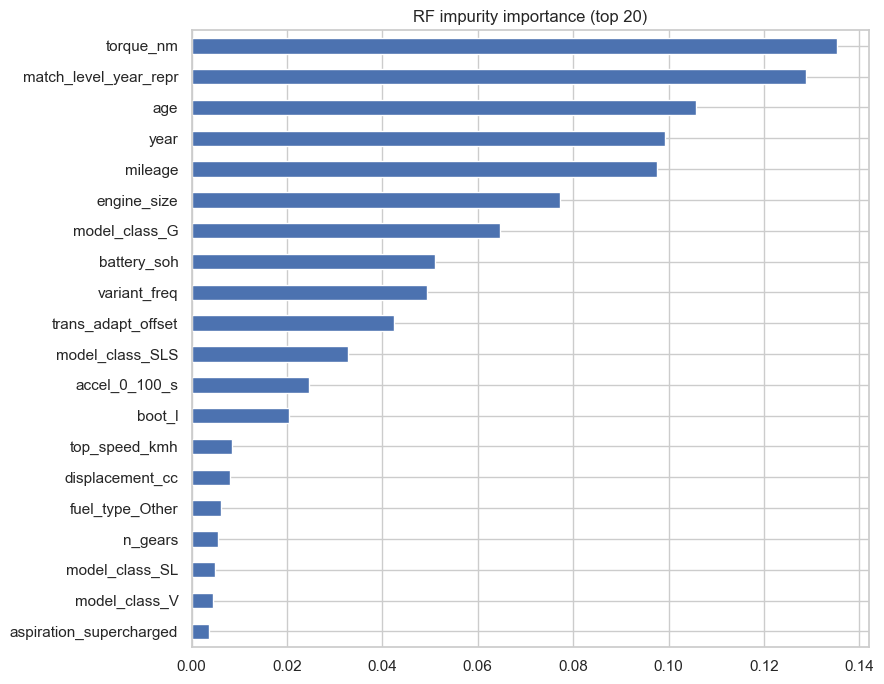

In [27]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(9, 7))
imp.plot.barh(ax=ax); ax.invert_yaxis()
ax.set_title("RF impurity importance (top 20)")
plt.tight_layout()

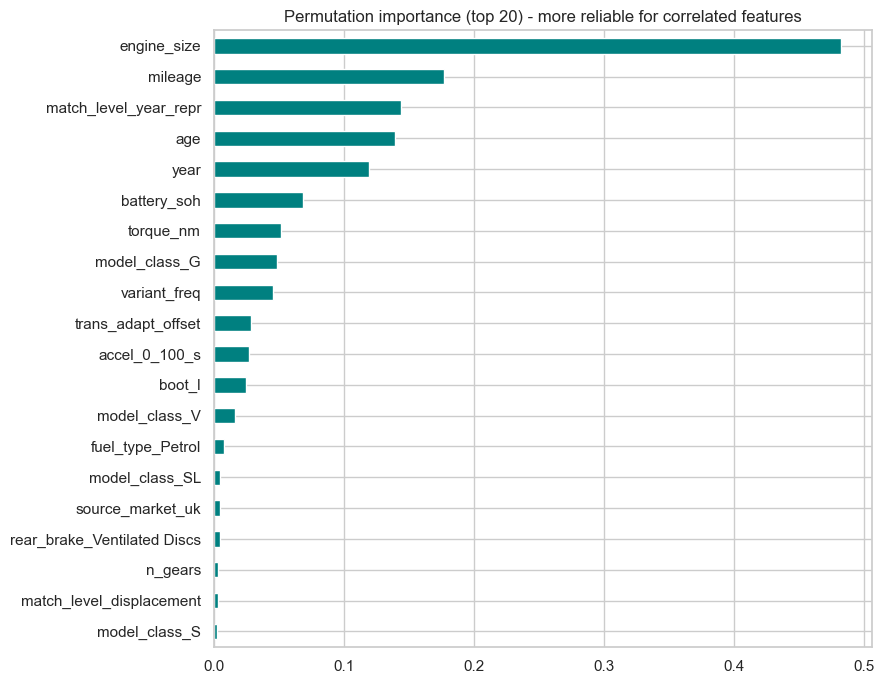

In [28]:
# Permutation importance re-predicts once per feature x repeat, so it is far slower than
# the impurity plot above. Subsample the test set for a fast directional read; raise
# n_sample / n_repeats for a finer (slower) estimate.
n_sample = min(2500, len(X_te))
X_perm = X_te.sample(n_sample, random_state=42)
y_perm = y_te.loc[X_perm.index]

perm = permutation_importance(rf, X_perm, y_perm, n_repeats=3, random_state=42, n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(9, 7))
perm_s.plot.barh(ax=ax, color="teal"); ax.invert_yaxis()
ax.set_title("Permutation importance (top 20) - more reliable for correlated features")
plt.tight_layout()

## 14 · Summary & recommendations for the RF model

**Data shape.** 36,819 rows × 26 columns; target `price_rm` (RM). Sources: Germany
(~65%) + UK (~35%).

**Duplicates.** No exact duplicates; **7 duplicate pairs (14 rows)** on the raw listing columns
— consider dropping to avoid train/test leakage.

**Missing values.** Confined to 5 spec columns (`boot_l` ~12%, `top_speed_kmh`,
`accel_0_100_s`, `torque_nm`, `n_gears`). **~83% of rows are complete.** Options:
complete-case (simple, keeps 83%) vs median-impute (keeps 100% but flattens `boot_l`).
For RF, median-impute is usually fine given the low missing rates.

**Target.** Right-skewed → **model `log1p(price_rm)`** and back-transform predictions;
this typically improves MAPE/RMSE.

**Data quality.** Fix `torque_nm` broken values (5 rows ≈ 320,440); check `engine_size==0`
(10 rows) against `fuel_type`; **drop `spec_matched`** (constant).

**Redundancy.** `engine_size` ↔ `displacement_cc` are near-duplicates — keep one
(`displacement_cc` is finer-grained). Watch other |r|>0.8 pairs from §12.

**Drivers of price (from correlation, η, and RF importance).** Age / year, mileage,
battery_soh, engine size / displacement, n_gears / n_cylinders, and `model_class` /
`variant` are the strongest. `source_market` (UK vs DE) reflects differing price levels —
keep it as a feature (or model per-market) so it isn't a hidden confound.

**Encoding for RF.** One-hot the low-cardinality categoricals; frequency- or
target-encode `variant` (197 levels — one-hot would explode dimensionality).

**Recommended starting feature set:** `age` (or `year`), `mileage`, `displacement_cc`,
`n_cylinders`, `n_gears`, `top_speed_kmh`, `torque_nm` (cleaned), `accel_0_100_s`,
`boot_l`, `battery_soh`, `trans_adapt_offset`, `model_class`, `variant` (encoded),
`transmission`, `fuel_type`, `aspiration`, `engine_config`, `source_market` — predicting
`log1p(price_rm)`.